In [1]:
import os
from pathlib import Path

baselines_fleetsdeg = 'baselines_fleetsdeg' 
testfolder = 'Sims'

if not os.path.exists(testfolder):
    os.makedirs(testfolder)

if not os.path.exists(baselines_fleetsdeg):
    os.makedirs(baselines_fleetsdeg)

In [2]:
import PV_ICE

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 14})
plt.rcParams['figure.figsize'] = (12, 5)

In [4]:
# This information helps with debugging and getting support :)
import sys, platform
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev686+gfb6f99a63


In [5]:
world_base_dir = r'C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines'
world_baseline_file = 'baseline_modules_mass_World.csv'

degradation_file = r'PVFleets_Degradation_Data.csv' # same folder

out_dir = 'baselines_fleetsdeg'

In [6]:
# --- Paths ---
baseline_path = os.path.join(world_base_dir, world_baseline_file)

# --- Read baseline ---
df_raw = pd.read_csv(baseline_path)
columns_order = df_raw.columns.tolist()
units_row = df_raw.iloc[0:1].copy()          # exact units row as in source

deg = pd.read_csv(degradation_file, sep=None, engine='python')

In [7]:
capacity_col  = 'new_Installed_Capacity_[MW]'
year_col  = 'year'

In [8]:
# Normalize column names (strip spaces, unify)
deg.columns = [c.strip() for c in deg.columns]
# Handle common header variants
rename_map = {}
for c in deg.columns:
    if 'Degradation' in c and 'Rate' in c:
        rename_map[c] = 'deg_rate'
    if '%' in c and ('Cohort' in c or 'cohort' in c):
        rename_map[c] = 'cohort_pct'
deg = deg.rename(columns=rename_map)

# Clean types
deg['deg_rate'] = pd.to_numeric(deg['deg_rate'], errors='coerce')
deg['cohort_pct'] = pd.to_numeric(deg['cohort_pct'], errors='coerce')
deg = deg.dropna(subset=['deg_rate', 'cohort_pct'])

In [9]:
# Work on a cleaned copy for math
df_base = df_raw.iloc[1:].copy()

In [10]:
# Coerce numerics to drop non-numeric rows (like the units row) for calculations
df_base[year_col] = pd.to_numeric(df_base[year_col], errors='coerce')
df_base[capacity_col] = pd.to_numeric(df_base[capacity_col], errors='coerce')


In [11]:
# --- Helper: prepend units row and enforce original column order ---
def finalize_with_units(df_calc: pd.DataFrame) -> pd.DataFrame:
    # Reorder to original columns (plus any new ones we ensured in units_row)
    df_calc = df_calc.reindex(columns=columns_order)
    # Align units row to same columns
    units_aligned = units_row.reindex(columns=columns_order)
    # Prepend units row exactly as it appeared
    out = pd.concat([units_aligned, df_calc], ignore_index=True)
    return out

In [12]:
year_num = pd.to_numeric(df_raw[year_col], errors='coerce')
mask_startyear = year_num >= 2017


In [13]:
saved_files = []

for _, row in deg.iterrows():
    rate = float(row['deg_rate'])        # typically negative in PV Fleets (e.g., -2.0 %/yr)
    pct = float(row['cohort_pct'])       # in percent (e.g., 5.0 means 5%)

    df_cohort = df_base.copy()

    # Scale the installed capacity by the cohort share
    df_cohort[capacity_col] = df_cohort[capacity_col] * (pct / 100.0)

    # Set mod_degradation to the positive number (e.g., 2.0 for -2.0), per your example
    df_cohort.loc[mask_startyear, 'mod_degradation'] = abs(rate)

    # Save per-cohort file
    base_name = "baseline_modules_mass_World"   # no .csv, just the stem
    out_name = f"{base_name}__cohort_{pct:0.2f}pct__deg_{abs(rate):0.1f}.csv"
    df_out = finalize_with_units(df_cohort)
    out_path = os.path.join(out_dir, out_name)
    df_out.to_csv(out_path, index=False)
    saved_files.append(Path(out_path).stem)

In [14]:
saved_files

['baseline_modules_mass_World__cohort_0.18pct__deg_5.2',
 'baseline_modules_mass_World__cohort_0.59pct__deg_4.2',
 'baseline_modules_mass_World__cohort_1.04pct__deg_3.4',
 'baseline_modules_mass_World__cohort_0.45pct__deg_3.2',
 'baseline_modules_mass_World__cohort_0.57pct__deg_3.0',
 'baseline_modules_mass_World__cohort_0.73pct__deg_2.8',
 'baseline_modules_mass_World__cohort_1.12pct__deg_2.6',
 'baseline_modules_mass_World__cohort_1.36pct__deg_2.4',
 'baseline_modules_mass_World__cohort_2.34pct__deg_2.2',
 'baseline_modules_mass_World__cohort_3.50pct__deg_2.0',
 'baseline_modules_mass_World__cohort_4.70pct__deg_1.8',
 'baseline_modules_mass_World__cohort_5.37pct__deg_1.6',
 'baseline_modules_mass_World__cohort_6.90pct__deg_1.4',
 'baseline_modules_mass_World__cohort_8.51pct__deg_1.2',
 'baseline_modules_mass_World__cohort_10.22pct__deg_1.0',
 'baseline_modules_mass_World__cohort_11.62pct__deg_0.8',
 'baseline_modules_mass_World__cohort_12.30pct__deg_0.6',
 'baseline_modules_mass_Worl

In [15]:
import re
deg_parts = [re.search(r'(deg_[^_]+)$', n).group(1) for n in saved_files if re.search(r'(deg_[^_]+)$', n)]


In [16]:
r1 = PV_ICE.Simulation(name='Sim1', path=testfolder)

path = Sims
Baseline folder directed to default:  C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\baselines


In [17]:
r1.createScenario(name='base', massmodulefile='baseline_modules_mass_World.csv', energymodulefile='baseline_modules_energy.csv')
r1.scenario['base'].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant


In [18]:
for ii in range(0, len(saved_files)):
    #ii = saved_files[0]
    ii_csv = saved_files[ii] + '.csv'
    ii_name = deg_parts[ii]
    r1.createScenario(name=ii_name, massmodulefile=ii_csv, energymodulefile='baseline_modules_energy.csv')
    r1.scenario[ii_name].addMaterials(['glass', 'silicon', 'silver', 'copper', 'aluminium_frames', 'encapsulant'])


Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files for:  aluminium_frames
Adding Mass AND Energy files for:  encapsulant
Adding Mass AND Energy files for:  glass
Adding Mass AND Energy files for:  silicon
Adding Mass AND Energy files for:  silver
Adding Mass AND Energy files for:  copper
Adding Mass AND Energy files fo

In [19]:
r1.calculateFlows()

>>>> Calculating Material Flows <<<<

Working on Scenario:  base
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  deg_5.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  deg_4.2
********************
Finished Area+Power Generation Calculations
==> Working on Material :  glass
==> Working on Material :  silicon
==> Working on Material :  silver
==> Working on Material :  copper
==> Working on Material :  aluminium_frames
==> Working on Material :  encapsulant
Working on Scenario:  d

In [20]:
USyearly, UScum = r1.aggregateResults()

C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  USyearly[nicekey+'_'+mat+'_'+self.name+'_'+scen] = self.scenario[scen].material[mat].matdataOut_m[keywd]
C:\Users\sayala\Documents\GitHub\PV_ICE\PV_ICE\main.py:2188: PerformanceWarning: DataFrame is highly fragmente

In [21]:
r1.saveSimulation()

:) Saved Input and Output Dataframes


In [26]:
UScum.to_csv('Cumulative.csv')
USyearly.to_csv('Yearly.csv')

In [ ]:
'''VirginStock_glass_Sim1_base_[Tonnes]	
VirginStock_silicon_Sim1_base_[Tonnes]	
VirginStock_silver_Sim1_base_[Tonnes]	
VirginStock_copper_Sim1_base_[Tonnes]	
VirginStock_aluminium_frames_Sim1_base_[Tonnes]	
VirginStock_encapsulant_Sim1_base_[Tonnes]	
VirginStock_Module_Sim1_base_[Tonnes]	
WasteAll_glass_Sim1_base_[Tonnes]	
WasteAll_silicon_Sim1_base_[Tonnes]	
WasteAll_silver_Sim1_base_[Tonnes]	
WasteAll_copper_Sim1_base_[Tonnes]	
WasteAll_aluminium_frames_Sim1_base_[Tonnes]	
WasteAll_encapsulant_Sim1_base_[Tonnes]	
WasteAll_Module_Sim1_base_[Tonnes]	
WasteEOL_glass_Sim1_base_[Tonnes]	
WasteEOL_silicon_Sim1_base_[Tonnes]	
WasteEOL_silver_Sim1_base_[Tonnes]	
WasteEOL_copper_Sim1_base_[Tonnes]	
WasteEOL_aluminium_frames_Sim1_base_[Tonnes]	
WasteEOL_encapsulant_Sim1_base_[Tonnes]	
WasteEOL_Module_Sim1_base_[Tonnes]	
WasteMFG_glass_Sim1_base_[Tonnes]	
WasteMFG_silicon_Sim1_base_[Tonnes]	
WasteMFG_silver_Sim1_base_[Tonnes]	
WasteMFG_copper_Sim1_base_[Tonnes]	
WasteMFG_aluminium_frames_Sim1_base_[Tonnes]	
WasteMFG_encapsulant_Sim1_base_[Tonnes]	
WasteMFG_Module_Sim1_base_[Tonnes]
'''

# POST PROCESSING

In [28]:
#WasteEOL_Module_Sim1_base_[Tonnes]	
#WasteEOL_Module_Sim1_deg_5.2_[Tonnes]


In [29]:
# 1. identify the deg_* columns
deg_cols = [c for c in UScum.columns if c.startswith("WasteEOL_Module_Sim1_deg_")]


In [30]:
# 2. create a new column with the row-wise sum
UScum["WasteEOL_Module_Sim1_deg_TOTAL_[Tonnes]"] = UScum[deg_cols].sum(axis=1)

In [32]:
UScum["WasteEOL_Module_Sim1_deg_TOTAL_[Tonnes]"]

year
1995    0.000000e+00
1996    2.284696e-02
1997    5.124831e-01
1998    3.455168e+00
1999    1.360150e+01
2000    3.922363e+01
2001    9.258202e+01
2002    1.901386e+02
2003    3.524236e+02
2004    6.034235e+02
2005    7.224170e+03
2006    1.434237e+04
2007    1.435182e+04
2008    1.437980e+04
2009    1.445487e+04
2010    1.463987e+04
2011    1.506240e+04
2012    2.557102e+04
2013    3.773751e+04
2014    5.329442e+04
2015    5.330394e+04
2016    5.333884e+04
2017    5.345326e+04
2018    5.379064e+04
2019    5.470148e+04
2020    7.742524e+04
2021    1.013002e+05
2022    1.417272e+05
2023    2.309796e+05
2024    4.465369e+05
2025    7.624491e+05
2026    1.146277e+06
2027    1.513376e+06
2028    2.193807e+06
2029    3.317954e+06
2030    4.834217e+06
2031    6.239926e+06
2032    8.767539e+06
2033    1.073549e+07
2034    1.468376e+07
2035    1.819694e+07
2036    2.092472e+07
2037    2.589454e+07
2038    2.897558e+07
2039    3.230275e+07
2040    3.872007e+07
2041    4.314320e+07
2042    

In [39]:
UScum.index

Index([1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030,
       2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042,
       2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050],
      dtype='int64', name='year')

In [48]:
total_col = 'WasteEOL_Module_Sim1_deg_TOTAL_[Tonnes]'

In [50]:
if "year" in UScum.columns:
    val_2030 = UScum.loc[UScum["year"] == 2030, total_col].squeeze()
else:
    # ensure index is integer (it looks like it already is)
    if UScum.index.dtype != "int64":
        UScum.index = UScum.index.astype(int)
    val_2030 = UScum.loc[2030, total_col]

val_2030

np.float64(4834217.295289044)

In [51]:
base_col_res = r'WasteEOL_Module_Sim1_base_[Tonnes]'
if "year" in UScum.columns:
    val_2030_base = UScum.loc[UScum["year"] == 2030, base_col_res].squeeze()
else:
    # ensure index is integer (it looks like it already is)
    if UScum.index.dtype != "int64":
        UScum.index = UScum.index.astype(int)
    val_2030_base = UScum.loc[2030, base_col_res]
val_2030_base

np.float64(1735935.956318894)

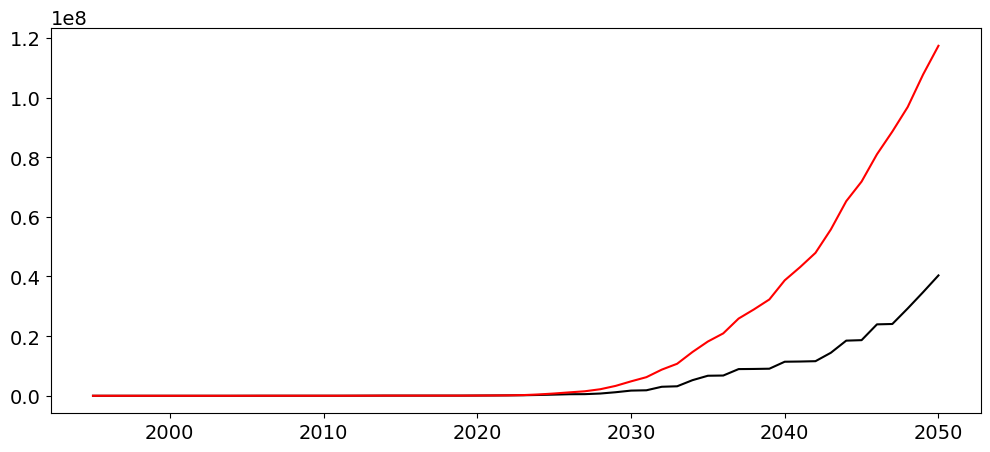

In [36]:
plt.plot(UScum["WasteEOL_Module_Sim1_base_[Tonnes]"], 'k')
plt.plot(UScum["WasteEOL_Module_Sim1_deg_TOTAL_[Tonnes]"], 'r')

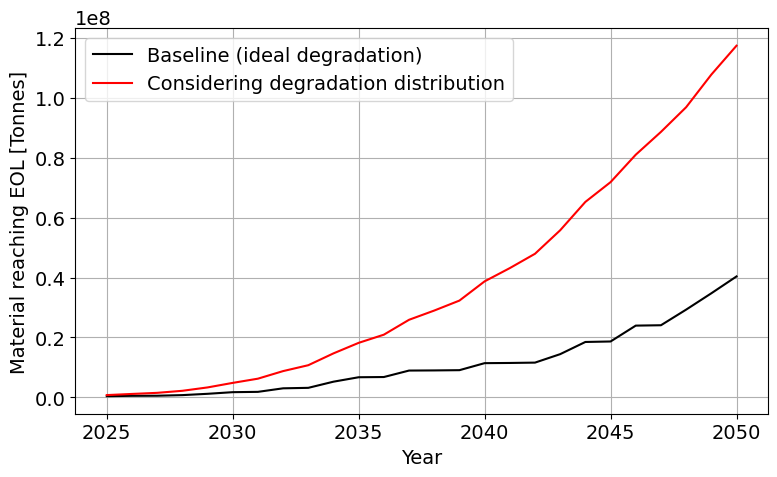

In [54]:
import matplotlib.pyplot as plt

# Slice from 2025 onward
UScum_2025 = UScum.loc[2025:]

plt.figure(figsize=(8,5))

plt.plot(UScum_2025.index, UScum_2025["WasteEOL_Module_Sim1_base_[Tonnes]"], 'k', label="Baseline (ideal degradation)")
plt.plot(UScum_2025.index, UScum_2025["WasteEOL_Module_Sim1_deg_TOTAL_[Tonnes]"], 'r', label="probability-weighted degradation outcome")

plt.xlabel("Year")
plt.ylabel("Material reaching EOL [Tonnes]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [55]:
plt.savefig("wasteEOL_deg_spread.png", dpi=300)  # high-quality PNG


<Figure size 1200x500 with 0 Axes>

In [56]:
val_2030_base, val_2030

(np.float64(4834217.295289044), np.float64(1735935.956318894))

In [58]:
val_2030*100/val_2030_base-100

np.float64(178.47901172230758)